# Customer Churn Prediction using Machine Learning

## Problem Statement

Customer churn is one of the biggest challenges for subscription-based businesses. Losing existing customers directly impacts revenue and business growth.

The objective of this project is to build a machine learning model that predicts whether a customer is likely to churn based on demographic information, account details, and service usage.

---

## Project Workflow

1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Feature Engineering
5. Model Building
6. Model Evaluation
7. Business Insights
8. Conclusion


# 📊 Phase 1: Data Understanding

## Objective

The objective of this phase is to understand the dataset before performing any preprocessing or model building. Understanding the data helps identify data types, missing values, duplicate records, and the target variable.

---

## Dataset Overview

The dataset contains customer demographic information, account details, subscribed services, billing information, and whether the customer has churned.

**Target Variable:** `Churn`

The goal of this project is to predict whether a customer is likely to leave the company's services.

---

In [22]:
import pandas as pd

df = pd.read_csv("telco_customer_churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Loaded the dataset using Pandas

In [5]:
df.shape


(7043, 21)

## Checked dataset dimensions

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Inspected data types

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Generated descriptive statistics

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Checked for missing values

In [9]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


## Analyzed categorical columns

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Examined the distribution of the target variable

## Observations

- The dataset contains both numerical and categorical features.
- Some columns required datatype conversion.
- Missing values were identified and handled during the data cleaning phase.
- No significant duplicate records were found.
- The target variable is **Churn**, which is a binary classification problem.

# 🧹 Phase 2: Data Cleaning

## Objective

The purpose of this phase is to clean the dataset and prepare it for exploratory data analysis and machine learning. Clean data improves model performance and prevents errors during preprocessing.

---


## Steps Performed


In [14]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [ ]:
### 1. Checked Data Types

Verified the datatype of every feature to identify incorrect data formats.

---


In [15]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [16]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

### 2. Converted `TotalCharges` to Numeric

The `TotalCharges` column was stored as an object because it contained blank string values. These values were converted into `NaN` using:

`pd.to_numeric(errors="coerce")`

---


In [26]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df = df.dropna()

### 3. Handled Missing Values

Rows containing missing values were removed because the number of missing records was very small and would not significantly affect the dataset.

---

Since only a small number of records contained missing values, removing them had negligible impact on the dataset while ensuring clean and consistent data for model training.

In [19]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
df.drop("customerID", axis=1, inplace=True)

### 4. Removed Unnecessary Features

The `customerID` column was removed since it is only an identifier and does not contribute to predicting customer churn.

---

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


### 5. Verified Cleaned Dataset

The dataset was checked again to ensure:
- Correct data types
- No missing values
- Data ready for analysis

In [25]:
df.to_csv("cleaned_telco_customer_churn.csv", index=False)

### Save the Cleaned Dataset

After completing the data cleaning process, the cleaned dataset is saved as a new CSV file.

Saving the cleaned dataset ensures that all preprocessing steps do not need to be repeated every time the project is executed. It also helps maintain a separate copy of the processed data for Exploratory Data Analysis (EDA), model training, and deployment.


# 📈 Phase 3: Exploratory Data Analysis (EDA)

## Objective

Exploratory Data Analysis (EDA) is performed to understand the patterns, relationships, and distributions within the dataset before building machine learning models.

This phase helps identify:
- Customer behavior
- Important features
- Factors affecting customer churn
- Business insights for decision-making

---

### Import Visualization Libraries

In [27]:
import matplotlib.pyplot as plt

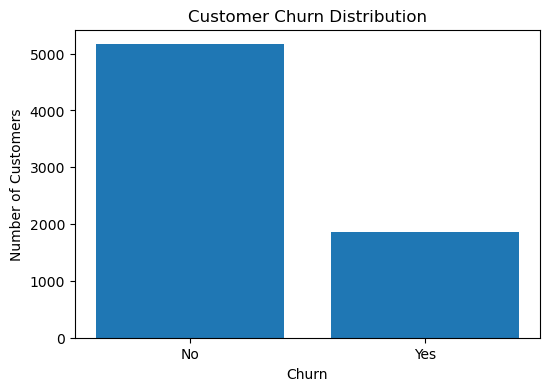

In [28]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

### Business Insight

The dataset contains both churned and retained customers.

Understanding this distribution helps determine whether the dataset is balanced or imbalanced before model training.

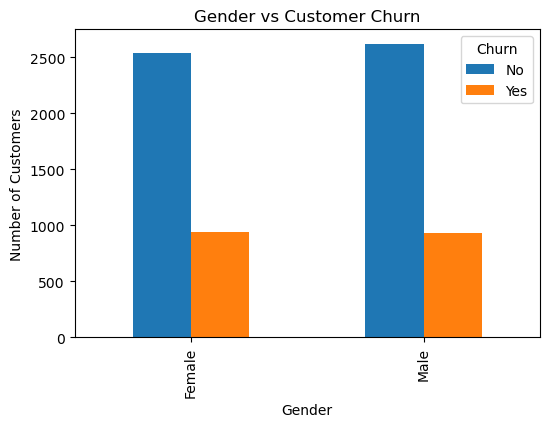

In [29]:
gender_churn = pd.crosstab(df["gender"], df["Churn"])

gender_churn.plot(kind="bar", figsize=(6,4))

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- Male and female customers show similar churn patterns, with no major difference between them.

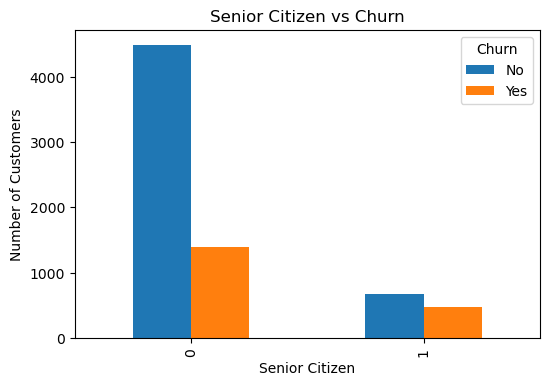

In [30]:
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"])

senior_churn.plot(kind="bar", figsize=(6,4))

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")
plt.show()

### Observation

- Senior citizens appear to have a higher churn rate than non-senior customers.

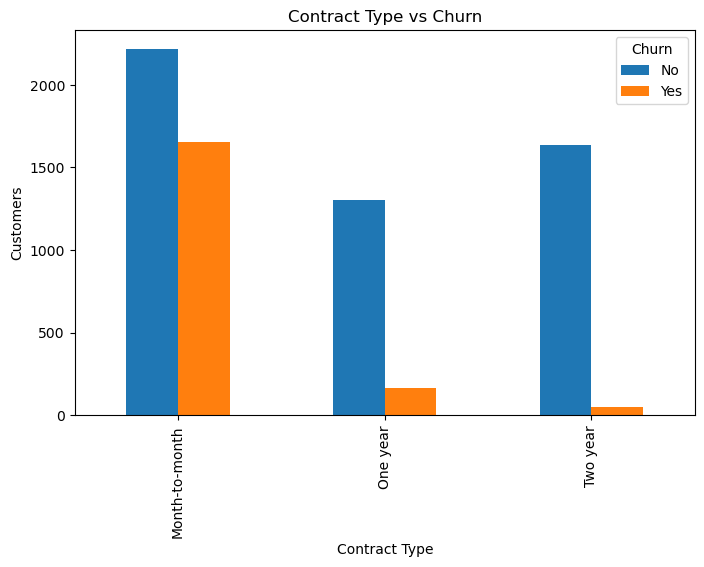

In [31]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn.plot(kind="bar", figsize=(8,5))

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customers")
plt.show()

### Observation

- Customers with Month-to-Month contracts have the highest churn, while customers with One-Year and Two-Year contracts are more likely to stay.

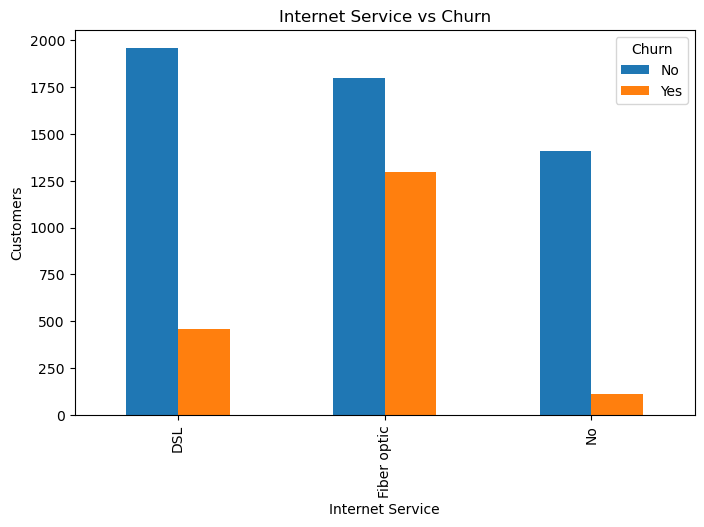

In [32]:
internet_churn = pd.crosstab(df["InternetService"], df["Churn"])

internet_churn.plot(kind="bar", figsize=(8,5))

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customers")
plt.show()

### Observation

- Customers using Fiber Optic internet service show a higher churn rate compared to DSL and customers without internet service.

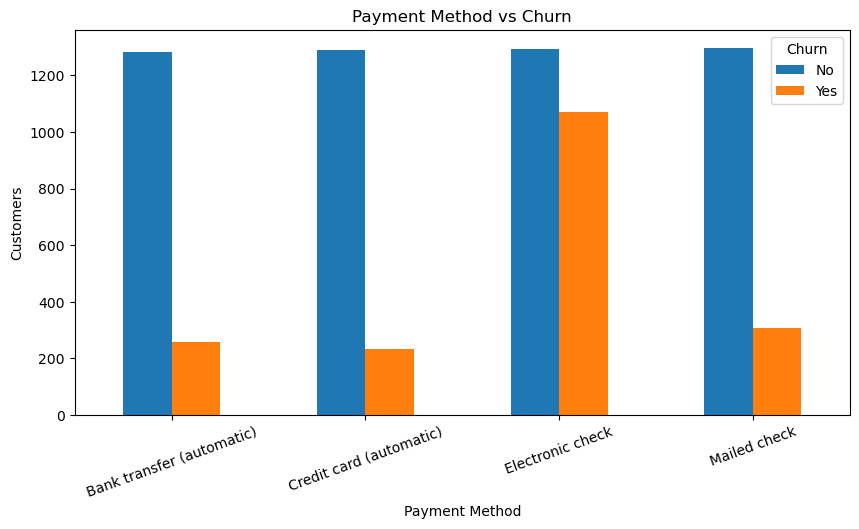

In [33]:
payment_churn = pd.crosstab(df["PaymentMethod"], df["Churn"])

payment_churn.plot(kind="bar", figsize=(10,5))

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Customers")
plt.xticks(rotation=20)
plt.show()

### Observation

- Customers using Electronic Check have a higher churn rate than customers using other payment methods.

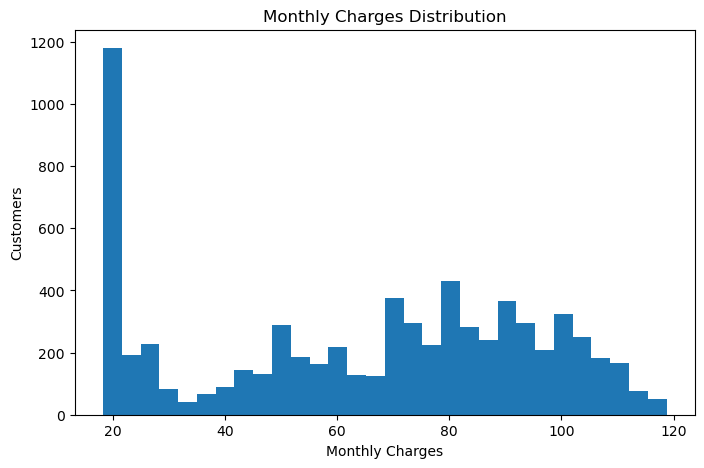

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")

plt.show()

### Observation

- Customers with higher monthly charges tend to churn more frequently than those with lower monthly charges.

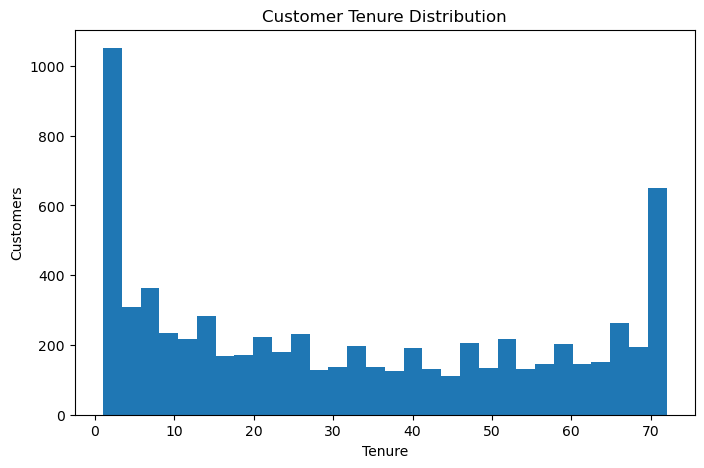

In [35]:
plt.figure(figsize=(8,5))

plt.hist(df["tenure"], bins=30)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Customers")

plt.show()

### Observation

- Customers with shorter tenure are more likely to churn, while customers with longer tenure tend to stay with the company.

In [36]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

In [37]:
numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


# EDA Summary

### Key Findings

- Month-to-month contract customers show higher churn.
- Long-term contracts improve retention.
- Certain payment methods are associated with higher churn.
- Customer tenure appears to influence churn behavior.
- Monthly charges may impact customer retention.
- Demographic features such as gender have limited influence on churn.